# Лабораторная 6. Свёрточные нейронные сети. Классификация изображений

**Задание.** Реализовать свёрточную сеть со свёрточными блоками двух видов:
а) `{Conv2d-ReLU-MaxPool}`; б) `{Conv2d-ReLU-Conv2d-ReLU-MaxPool}`.

Для выборки MNIST или FashionMNIST, или одной из выборок модуля `Datasets`
выбрать сочетание *некоторых* из следующих гиперпараметров, дающих наилучшее
качество классификации: 1) коэффициент обучения; 2) тип свёрточных блоков
(типы а или б) и их количество; 3) параметры свёртки (класс `Conv2d`):
размер фильтра `kernel_size` и шаг `stride`; 4) параметры пуллинга (класс
`MaxPool2d`): размер окна `kernel_size` и шаг `stride`.

Оценить количество эпох, достаточное для классификации с точностью (метрика
accuracy) не меньшей 90% для свёрточной сети с выбранным сочетанием указанных
параметров.

Дополнительно (по выбору): варьирование параметров обучения, других
гиперпараметров модели, использование различных оптимизаторов.

## 1. Теория

### Данные

MNIST, изображения $28 \times 28$ в градациях серого, 10 классов. Для перебора
гиперпараметров берётся подвыборка 3000 обучающих и 1500 тестовых изображений,
финальная модель обучается на 12000 и проверяется на полной тестовой выборке из
10000. Яркости делятся на 255 и нормируются стандартными для MNIST значениями
$\mu = 0.1307$, $\sigma = 0.3081$.

### Свёртка

Свёртка применяет одно и то же ядро $K$ размера $k \times k$ ко всем положениям
изображения:

$$(X * K)_{ij} = \sum_{u=0}^{k-1}\sum_{v=0}^{k-1} X_{\,i s + u,\; j s + v}\,K_{uv},$$

где $s$ это шаг (`stride`). Число параметров слоя равно $k^2$ на канал и не
зависит от размера изображения.

### Размер выхода

Для входа $n \times n$, ядра $k$, шага $s$ и дополнения $p$

$$n_{\text{out}} = \left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1 .$$

Той же формуле подчиняется пуллинг: `MaxPool2d` берёт максимум по окну
$k \times k$ с шагом $s$.

### Рецептивное поле

Область исходного изображения, влияющая на значение нейрона, растёт по слоям
как

$$r_{l} = r_{l-1} + (k_l - 1)\prod_{i<l} s_i .$$

Две свёртки $3\times3$ подряд дают рецептивное поле $5\times5$ при $18$
параметрах против $25$ у одной свёртки $5\times5$.

### Функция потерь

Перекрёстная энтропия $L = -\frac1n\sum_k \log p_{y_k}(x_k)$, где $p$ это
мягкий максимум выходов сети.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| коэффициент обучения | $0.005$, $0.01$, $0.05$, $0.1$ |
| тип блока | а) Conv-ReLU-Pool; б) Conv-ReLU-Conv-ReLU-Pool |
| число блоков | 1, 2 |
| `kernel_size` свёртки | 3, 5, 7 |
| `stride` свёртки | 1, 2 |
| `kernel_size` пуллинга | 2, 3 |
| `stride` пуллинга | 2, 3 |
| оптимизатор | SGD с моментом, Adam |

Перебор в два этапа: сначала основная сетка по первым четырём параметрам, затем
параметры свёртки, пуллинга и оптимизатор на лучшей найденной конфигурации.

### Мера качества

Доля верных ответов $\mathrm{accuracy} = \frac1n \sum_k [\,\hat y_k = y_k\,]$.

## 2. Данные

In [1]:
import os
import struct
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(20260905)
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, устройство: {DEVICE}')

torch 2.11.0+cu128, устройство: cuda


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    for c in [os.environ.get('MNIST_DIR'),
              '../../bachelor/Perceptron/data_generation/MNIST/raw',
              'data/MNIST/raw']:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
Xtr_all = read_idx(D / 'train-images-idx3-ubyte')
ytr_all = read_idx(D / 'train-labels-idx1-ubyte')
Xte_all = read_idx(D / 't10k-images-idx3-ubyte')
yte_all = read_idx(D / 't10k-labels-idx1-ubyte')

MEAN, STD = 0.1307, 0.3081


def to_tensor(X, y):
    """Изображения в тензор (N, 1, 28, 28) с нормировкой, метки в long."""
    xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0  # ось 1 это канал
    xt = (xt - MEAN) / STD
    return xt.to(DEVICE), torch.tensor(y, dtype=torch.long).to(DEVICE)


idx_tr = RNG.choice(len(Xtr_all), 3000, replace=False)
idx_te = RNG.choice(len(Xte_all), 1500, replace=False)
Xg, yg = to_tensor(Xtr_all[idx_tr], ytr_all[idx_tr])
Xv, yv = to_tensor(Xte_all[idx_te], yte_all[idx_te])
print(f'сетка гиперпараметров: обучающая {tuple(Xg.shape)}, тестовая {tuple(Xv.shape)}')

сетка гиперпараметров: обучающая (3000, 1, 28, 28), тестовая (1500, 1, 28, 28)


## 3. Архитектура и обучение

In [3]:
class ConvNet(nn.Module):
    """Свёрточная сеть из блоков двух видов.
    block='a': Conv-ReLU-MaxPool; block='b': Conv-ReLU-Conv-ReLU-MaxPool."""

    def __init__(self, block='a', n_blocks=2, ks=3, stride=1,
                 pool_k=2, pool_s=2, channels=8):
        super().__init__()
        layers, c_in, size = [], 1, 28  # size это текущий размер карты признаков
        for i in range(n_blocks):
            c_out = channels * (i + 1)
            pad = ks // 2
            layers += [nn.Conv2d(c_in, c_out, ks, stride, pad), nn.ReLU()]
            size = (size + 2 * pad - ks) // stride + 1  # формула размера выхода
            if block == 'b':
                layers += [nn.Conv2d(c_out, c_out, ks, 1, pad), nn.ReLU()]
            if size >= pool_k:  # пуллинг возможен, пока карта не меньше окна
                layers += [nn.MaxPool2d(pool_k, pool_s)]
                size = (size - pool_k) // pool_s + 1
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.out_size = size
        self.classifier = nn.Linear(c_in * size * size, 10)

    def forward(self, x):
        # flatten(1) вытягивает карту признаков в вектор, сохраняя ось объектов
        return self.classifier(self.features(x).flatten(1))

In [4]:
def evaluate(model, X, y, batch=512):
    """Доля верных ответов, считается батчами."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for s in range(0, len(X), batch):
            correct += (model(X[s:s + batch]).argmax(1) == y[s:s + batch]).sum().item()
    return correct / len(X)


def train_model(model, Xtr, ytr, Xte, yte, lr=0.05, epochs=8, batch=64,
                optimizer='sgd', seed=0):
    """Обучение с записью accuracy после каждой эпохи."""
    torch.manual_seed(seed)
    opt = (torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
           if optimizer == 'sgd' else torch.optim.Adam(model.parameters(), lr=lr))
    lossf = nn.CrossEntropyLoss()
    hist, t0 = [], time.time()
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr), device=Xtr.device)  # новый порядок объектов
        for s in range(0, len(Xtr), batch):
            b = perm[s:s + batch]
            opt.zero_grad()
            lossf(model(Xtr[b]), ytr[b]).backward()
            opt.step()
        hist.append(evaluate(model, Xte, yte))
    return np.array(hist), time.time() - t0


def epochs_to_level(hist, level=0.90):
    """Номер первой эпохи, на которой accuracy достигла level, иначе None."""
    for i, acc in enumerate(hist, start=1):
        if acc >= level:
            return i
    return None

In [5]:
demo = ConvNet(block='b', n_blocks=2, ks=3)
print(demo)
print(f'\nразмер карты признаков перед классификатором: '
      f'{demo.out_size} x {demo.out_size}')
print(f'число параметров: {sum(p.numel() for p in demo.parameters()):,}')

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)

размер карты признаков перед классификатором: 7 x 7
число параметров: 12,002


## 4. Основная сетка гиперпараметров

In [6]:
EPOCHS = 6
rows = []
t_start = time.time()

for lr, block, n_blocks, ks in itertools.product(
        [0.005, 0.01, 0.05, 0.1], ['a', 'b'], [1, 2], [3, 5, 7]):
    torch.manual_seed(20260905)
    model = ConvNet(block=block, n_blocks=n_blocks, ks=ks).to(DEVICE)
    hist, dt = train_model(model, Xg, yg, Xv, yv, lr=lr, epochs=EPOCHS)
    rows.append(dict(stage='основная', lr=lr, block=block, n_blocks=n_blocks,
                     ks=ks, stride=1, pool_k=2, pool_s=2, optimizer='sgd',
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=epochs_to_level(hist),
                     params=sum(p.numel() for p in model.parameters()),
                     time=round(dt, 1), curve=list(np.round(hist, 4))))

grid1 = pd.DataFrame(rows)
print(f'{len(grid1)} конфигураций за {time.time() - t_start:.0f} с')
grid1.sort_values('best_acc', ascending=False).head(10)[
    ['lr', 'block', 'n_blocks', 'ks', 'best_acc', 'epochs_to_90', 'params', 'time']]

48 конфигураций за 15 с


,lr,block,n_blocks,ks,best_acc,epochs_to_90,params,time
20,0.010,b,1,7,0.966000,2.0,19234,0.3
27,0.050,a,2,3,0.964000,1.0,9098,0.3
8,0.005,b,1,7,0.962667,2.0,19234,0.3
22,0.010,b,2,5,0.962667,3.0,19298,0.4
16,0.010,a,2,5,0.962667,2.0,11274,0.3
28,0.050,a,2,5,0.962667,2.0,11274,0.3
19,0.010,b,1,5,0.962000,2.0,17506,0.3
5,0.005,a,2,7,0.959333,2.0,14538,0.3
25,0.050,a,1,5,0.959333,1.0,15898,0.2
17,0.010,a,2,7,0.959333,2.0,14538,0.3


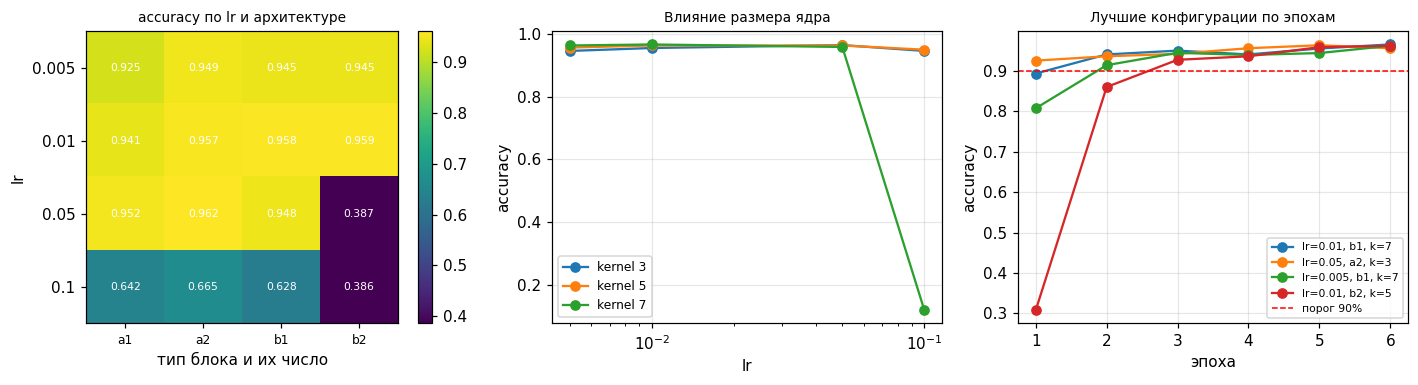

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
piv = grid1.pivot_table(index='lr', columns=['block', 'n_blocks'], values='best_acc')
im = axes[0].imshow(piv.values, cmap='viridis', aspect='auto')
axes[0].set_xticks(range(len(piv.columns)))
axes[0].set_xticklabels([f'{b}{n}' for b, n in piv.columns], fontsize=8)
axes[0].set_yticks(range(len(piv.index))); axes[0].set_yticklabels(piv.index)
axes[0].set_xlabel('тип блока и их число'); axes[0].set_ylabel('lr')
axes[0].set_title('accuracy по lr и архитектуре', fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f'{piv.values[i, j]:.3f}', ha='center', va='center',
                     fontsize=7, color='white')
plt.colorbar(im, ax=axes[0])

for ks in [3, 5, 7]:
    s = grid1[grid1.ks == ks].groupby('lr')['best_acc'].max()
    axes[1].plot(s.index, s.values, marker='o', label=f'kernel {ks}')
axes[1].set_xscale('log'); axes[1].set_xlabel('lr'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Влияние размера ядра', fontsize=9)
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

for _, r in grid1.sort_values('best_acc', ascending=False).head(4).iterrows():
    axes[2].plot(range(1, EPOCHS + 1), r['curve'], marker='o',
                 label=f"lr={r['lr']}, {r['block']}{r['n_blocks']}, k={r['ks']}")
axes[2].axhline(0.90, color='red', ls='--', lw=1, label='порог 90%')
axes[2].set_xlabel('эпоха'); axes[2].set_ylabel('accuracy')
axes[2].set_title('Лучшие конфигурации по эпохам', fontsize=9)
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5. Параметры свёртки, пуллинга и оптимизатор

In [8]:
best1 = grid1.sort_values('best_acc', ascending=False).iloc[0]
print(f'лучшая конфигурация основной сетки: lr={best1["lr"]}, блок {best1["block"]}, '
      f'блоков {best1["n_blocks"]}, kernel {best1["ks"]}, accuracy {best1["best_acc"]:.4f}')

rows = []
for stride, pool_k, pool_s in itertools.product([1, 2], [2, 3], [2, 3]):
    torch.manual_seed(20260905)
    model = ConvNet(block=best1['block'], n_blocks=int(best1['n_blocks']),
                    ks=int(best1['ks']), stride=stride, pool_k=pool_k,
                    pool_s=pool_s).to(DEVICE)
    hist, dt = train_model(model, Xg, yg, Xv, yv, lr=float(best1['lr']), epochs=EPOCHS)
    rows.append(dict(stage='свёртка и пуллинг', lr=best1['lr'], block=best1['block'],
                     n_blocks=best1['n_blocks'], ks=best1['ks'], stride=stride,
                     pool_k=pool_k, pool_s=pool_s, optimizer='sgd',
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=epochs_to_level(hist),
                     params=sum(p.numel() for p in model.parameters()),
                     time=round(dt, 1), curve=list(np.round(hist, 4))))

for opt_name, lr in [('adam', 0.001), ('adam', 0.003), ('sgd', float(best1['lr']))]:
    torch.manual_seed(20260905)
    model = ConvNet(block=best1['block'], n_blocks=int(best1['n_blocks']),
                    ks=int(best1['ks'])).to(DEVICE)
    hist, dt = train_model(model, Xg, yg, Xv, yv, lr=lr, epochs=EPOCHS,
                           optimizer=opt_name)
    rows.append(dict(stage='оптимизатор', lr=lr, block=best1['block'],
                     n_blocks=best1['n_blocks'], ks=best1['ks'], stride=1,
                     pool_k=2, pool_s=2, optimizer=opt_name,
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=epochs_to_level(hist),
                     params=sum(p.numel() for p in model.parameters()),
                     time=round(dt, 1), curve=list(np.round(hist, 4))))

grid2 = pd.DataFrame(rows)
print(grid2[['stage', 'stride', 'pool_k', 'pool_s', 'optimizer', 'lr',
             'best_acc', 'epochs_to_90', 'params', 'time']].round(4).to_string(index=False))

лучшая конфигурация основной сетки: lr=0.01, блок b, блоков 1, kernel 7, accuracy 0.9660


            stage  stride  pool_k  pool_s optimizer    lr  best_acc  epochs_to_90  params  time
свёртка и пуллинг       1       2       2       sgd 0.010    0.9653             2   19234   0.3
свёртка и пуллинг       1       2       3       sgd 0.010    0.9573             2   10034   0.3
свёртка и пуллинг       1       3       2       sgd 0.010    0.9673             1   17074   0.3
свёртка и пуллинг       1       3       3       sgd 0.010    0.9613             2   10034   0.3
свёртка и пуллинг       2       2       2       sgd 0.010    0.9587             2    7474   0.3
свёртка и пуллинг       2       2       3       sgd 0.010    0.9453             3    5554   0.3
свёртка и пуллинг       2       3       2       sgd 0.010    0.9620             2    6434   0.2
свёртка и пуллинг       2       3       3       sgd 0.010    0.9640             2    4834   0.3
      оптимизатор       1       2       2      adam 0.001    0.9587             2   19234   0.3
      оптимизатор       1       2       

In [9]:
allres = pd.concat([grid1, grid2], ignore_index=True)
allres.drop(columns='curve').to_csv('results.csv', index=False)
print(f'всего {len(allres)} конфигураций, сохранено в results.csv')

всего 59 конфигураций, сохранено в results.csv


## 6. Число эпох до точности 90%

In [10]:
sub = allres.dropna(subset=['epochs_to_90'])
print(f'достигли 90%: {len(sub)} из {len(allres)} конфигураций')
print(f'\nраспределение числа эпох до 90%:')
print(sub.epochs_to_90.value_counts().sort_index().to_string())
print(f'\nсреди тех, кто дошёл: медиана {sub.epochs_to_90.median():.0f} эпох, '
      f'минимум {sub.epochs_to_90.min():.0f}, максимум {sub.epochs_to_90.max():.0f}')
print(f'\nконфигурации, не достигшие 90% за {EPOCHS} эпох:')
print(allres[allres.epochs_to_90.isna()][
    ['lr', 'block', 'n_blocks', 'ks', 'stride', 'pool_k', 'pool_s',
     'optimizer', 'best_acc']].to_string(index=False))

достигли 90%: 49 из 59 конфигураций

распределение числа эпох до 90%:
epochs_to_90
1.0     9
2.0    21
3.0    14
4.0     3
5.0     1
6.0     1

среди тех, кто дошёл: медиана 2 эпох, минимум 1, максимум 6

конфигурации, не достигшие 90% за 6 эпох:
  lr block  n_blocks  ks  stride  pool_k  pool_s optimizer  best_acc
0.05     b         2   5       1       2       2       sgd  0.114667
0.05     b         2   7       1       2       2       sgd  0.114667
0.10     a         1   3       1       2       2       sgd  0.858667
0.10     a         1   7       1       2       2       sgd  0.118667
0.10     a         2   7       1       2       2       sgd  0.114667
0.10     b         1   3       1       2       2       sgd  0.882667
0.10     b         1   5       1       2       2       sgd  0.887333
0.10     b         1   7       1       2       2       sgd  0.114667
0.10     b         2   5       1       2       2       sgd  0.114667
0.10     b         2   7       1       2       2       sgd  0.1

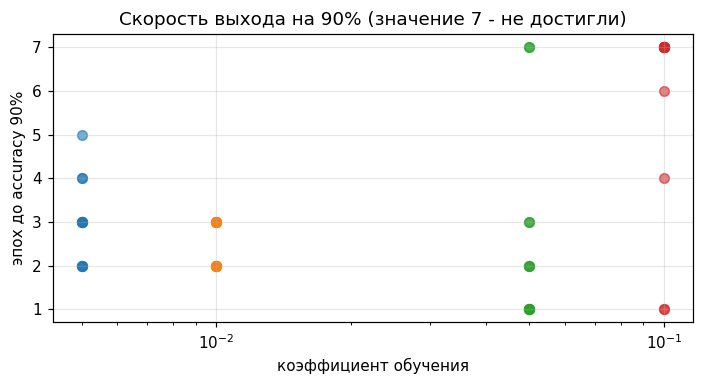

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for lr in sorted(grid1.lr.unique()):
    s = grid1[grid1.lr == lr]
    ax.scatter([lr] * len(s), s.epochs_to_90.fillna(EPOCHS + 1), alpha=0.6, s=40)
ax.set_xscale('log'); ax.set_xlabel('коэффициент обучения')
ax.set_ylabel('эпох до accuracy 90%')
ax.set_title(f'Скорость выхода на 90% (значение {EPOCHS + 1} - не достигли)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Финальная модель

In [12]:
best = allres.sort_values('best_acc', ascending=False).iloc[0]
print('лучшее сочетание гиперпараметров:')
for k in ['lr', 'block', 'n_blocks', 'ks', 'stride', 'pool_k', 'pool_s', 'optimizer']:
    print(f'  {k}: {best[k]}')
print(f'  accuracy на сетке: {best["best_acc"]:.4f}')

idx_big = RNG.choice(len(Xtr_all), 12000, replace=False)
Xb, yb = to_tensor(Xtr_all[idx_big], ytr_all[idx_big])
Xt, yt = to_tensor(Xte_all, yte_all)

torch.manual_seed(20260905)
final = ConvNet(block=best['block'], n_blocks=int(best['n_blocks']), ks=int(best['ks']),
                stride=int(best['stride']), pool_k=int(best['pool_k']),
                pool_s=int(best['pool_s'])).to(DEVICE)
hist_final, dt_final = train_model(final, Xb, yb, Xt, yt, lr=float(best['lr']),
                                   epochs=12, optimizer=best['optimizer'])
print(f'\nобучение на 12000 изображениях, 12 эпох: {dt_final:.0f} с')
print(f'accuracy на полной тестовой выборке (10000): {hist_final[-1]:.4f}')
print(f'эпох до 90%: {epochs_to_level(hist_final)}')

лучшее сочетание гиперпараметров:
  lr: 0.01
  block: b
  n_blocks: 1
  ks: 7
  stride: 1
  pool_k: 3
  pool_s: 2
  optimizer: sgd
  accuracy на сетке: 0.9673



обучение на 12000 изображениях, 12 эпох: 2 с
accuracy на полной тестовой выборке (10000): 0.9799
эпох до 90%: 1


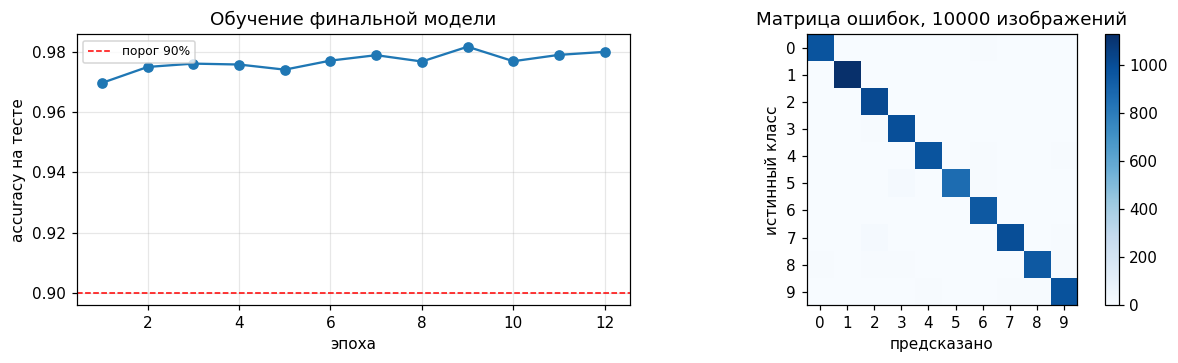

самые частые путаницы:
  7 -> 2: 17
  5 -> 3: 14
  9 -> 8: 8
  8 -> 3: 7
  7 -> 9: 7


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(range(1, len(hist_final) + 1), hist_final, marker='o')
axes[0].axhline(0.90, color='red', ls='--', lw=1, label='порог 90%')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на тесте')
axes[0].set_title('Обучение финальной модели'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

from sklearn.metrics import confusion_matrix
final.eval()
with torch.no_grad():  # предсказания считаются батчами и переносятся на CPU
    pred = torch.cat([final(Xt[s:s + 512]).argmax(1) for s in range(0, len(Xt), 512)])
cm = confusion_matrix(yte_all, pred.cpu().numpy())
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('Матрица ошибок, 10000 изображений')
axes[1].set_xlabel('предсказано'); axes[1].set_ylabel('истинный класс')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

pairs = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j]
pairs.sort(reverse=True)
print('самые частые путаницы:')
for n, i, j in pairs[:5]:
    print(f'  {i} -> {j}: {n}')

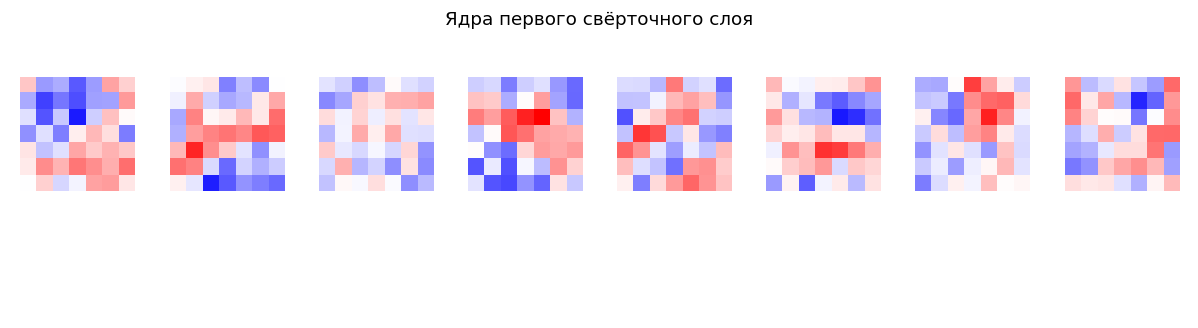

In [14]:
w = final.features[0].weight.detach().cpu().numpy()
n = min(len(w), 16)
fig, axes = plt.subplots(2, 8, figsize=(11, 2.8))
for i, ax in enumerate(axes.ravel()):
    ax.axis('off')
    if i < n:
        ax.imshow(w[i, 0], cmap='bwr', vmin=-np.abs(w).max(), vmax=np.abs(w).max())
fig.suptitle('Ядра первого свёрточного слоя', y=1.05)
plt.tight_layout()
plt.show()